Yield curve as of 06/11/2026
   maturity  par_yield
0      0.25     0.0378
1      0.50     0.0381
2      1.00     0.0385
3      2.00     0.0405
4      3.00     0.0409
5      5.00     0.0418
6      7.00     0.0431
7     10.00     0.0445
8     20.00     0.0496
9     30.00     0.0495
Spot rates as of 06/11/2026
0.25y: 3.7800%
0.50y: 3.8100%
1.00y: 3.8500%
2.00y: 4.0971%
3.00y: 4.1365%
5.00y: 4.2341%
7.00y: 4.3806%
10.00y: 4.5385%
20.00y: 5.3090%
30.00y: 4.6587%
Forward rates as of 06/11/2026
f0.25y,0.5y: 3.8400%
f0.5y,1y: 3.8900%
f1y,2y: 4.3449%
f2y,3y: 4.2154%
f3y,5y: 4.3807%
f5y,7y: 4.7476%
f7y,10y: 4.9077%
f10y,20y: 6.0853%
f20y,30y: 3.3702%


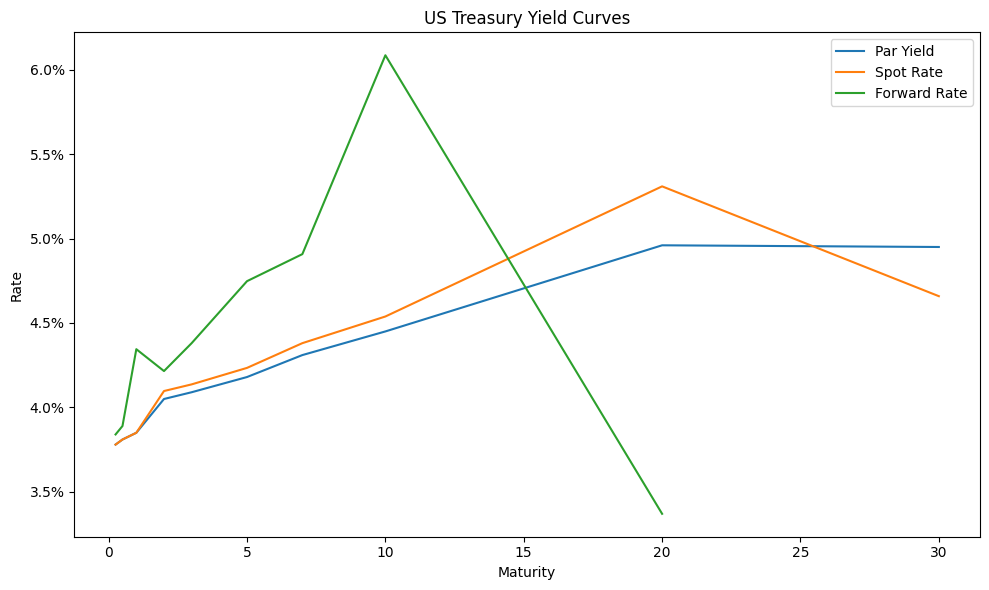

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


url = "https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rates.csv/2026/all?type=daily_treasury_yield_curve"
data = pd.read_csv(url)

maturities = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
columns = ['3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr']
latest = data.iloc[0]

yield_curve = pd.DataFrame({
    "maturity": maturities,
    "par_yield": [latest[col]/100 for col in columns]
})
print(f"Yield curve as of {latest['Date']}")
print(yield_curve)


known_spot_rates = {}
known_spot_rates[0.25] = yield_curve[yield_curve["maturity"] == 0.25]["par_yield"].values[0]
known_spot_rates[0.5] = yield_curve[yield_curve["maturity"] == 0.5]["par_yield"].values[0]
known_spot_rates[1] = yield_curve[yield_curve["maturity"] == 1]["par_yield"].values[0]

def interpolate_spot_rate(t, known_spot_rates, yield_curve):
  t_left = max(known_spot_rates.keys())
  s_left = known_spot_rates[t_left] # latest spot rate known
  t_right = yield_curve[yield_curve["maturity"] > t_left]["maturity"].values[0] # next known par yield rate
  s_right = yield_curve[yield_curve["maturity"] == t_right]["par_yield"].values[0] # we use the yield curve as an approximation for spot rate to the right

  return s_left + (t - t_left)/(t_right - t_left) * (s_right - s_left)

def get_rate(t, known_spot_rates, yield_curve): # helper to get the known spot rate if there is an otherwise interpolate
  if t in known_spot_rates:
    return known_spot_rates[t]
  else:
    return interpolate_spot_rate(t, known_spot_rates, yield_curve)

def bootstrap(t, known_spot_rates, yield_curve):
  coupon = yield_curve[yield_curve["maturity"] == t]["par_yield"].values[0] * 100 / 2
  PV_of_coupons = sum(coupon / (1 + get_rate(i, known_spot_rates, yield_curve)) ** i for i in np.arange(0.5, t, 0.5))
  new_spot = ((coupon + 100) / (100 - PV_of_coupons)) ** (1/t) - 1
  known_spot_rates[t] = new_spot
  return new_spot

for maturity in [2, 3, 5, 7, 10, 20, 30]:
    bootstrap(maturity, known_spot_rates, yield_curve)

print(f"Spot rates as of {latest['Date']}")
for maturity,spot_rate in known_spot_rates.items():
  print(f"{maturity:.2f}y: {spot_rate:.4%}")

# Calculate Forward Rate
def forward_rate(m, n, known_spot_rates):
  rate = ((1 + known_spot_rates[n]) ** n / (1 + known_spot_rates[m]) ** m) ** (1/(n-m)) - 1
  return rate

forward_rates = {}
for i in range(len(maturities) -1):
  m = maturities[i]
  n = maturities[i + 1]
  forward_rates[(m, n)] = forward_rate(m, n, known_spot_rates)

print(f"Forward rates as of {latest['Date']}")
for (m, n), rate in forward_rates.items():
  print(f"f{m}y,{n}y: {rate:.4%}")


# Plot
# Par yield curve
plt.figure(figsize=(10,6))
plt.plot(yield_curve['maturity'], yield_curve['par_yield'], label="Par Yield")

# Spot yield curve
plt.plot(list(known_spot_rates.keys()), list(known_spot_rates.values()), label="Spot Rate")

# Forward rate curve
x = [m for (m,n) in forward_rates.keys()]
plt.plot(x, list(forward_rates.values()), label="Forward Rate")

plt.title("US Treasury Yield Curves")
plt.xlabel("Maturity")
plt.ylabel("Rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.1%}"))
plt.tight_layout()
plt.legend()
plt.show()